# GUV Image Analysis Pipeline

This notebook contains a pipeline for analyzing GUV (Giant Unilamellar Vesicle) images. It processes both single-frame and time-trace data from .tif files.

(under construction)

In [54]:
import csv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from scipy.interpolate import make_interp_spline

# Import custom modules
import vesicles as vs

# set up autoreload on all files
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## GUV Class Definition

In [48]:
class GUV:
    def __init__(self):
        self.exp_id = 0
        self.label = 'any_label'
        self.comment = []
        self.use_it = []
        self.crop_it = []
        self.dt = 1

## Helper Functions

### `get_data_selections(run_id)`

This function reads GUV data from an Excel file and returns a list of GUV objects for a specific run ID.
We define a `GUV` class to store properties of a single GUV movie.

In [49]:
def get_data_selections(run_id,filename):
    wb = load_workbook(filename)
    sheet_files = wb['guvs']
    
    # Create a dictionary of column names
    Header = {COL[0].value: idx for idx, COL in enumerate(sheet_files.iter_cols(1, sheet_files.max_column))}
    
    Guv_list = []
    for row_cells in sheet_files.iter_rows(min_row=2, max_row=sheet_files.max_row):
        Guv = GUV()
        Guv.exp_id = row_cells[Header["exp_id"]].value
        Guv.movie_id = row_cells[Header["movie_id"]].value
        Guv.label = row_cells[Header["guv_label"]].value
        Guv.use_it = row_cells[Header["use"]].value
        Guv.crop_it = row_cells[Header["crop"]].value
        Guv.dt = row_cells[Header["dt(s)"]].value
        if Guv.exp_id == run_id:
            Guv_list.append(Guv)
    return Guv_list

## Main Analysis Pipeline

Fetch the experiment parameters: these are listed in 'A00_init and include paths, movienames etc.'. An experiment has a unique index. Since I keep some local copies, I added a decimal to this index to tell the code where to look (local or remote)

In [50]:
expi = 0.2  # 0.2: Charu's test data, decimal .2 refers to remote drive
movie_to_use_list = [0]  #should be identical to 'movie-id' list in excel
movie_simbol_list = ['r']

initval = vs.A00_init.get_exps(expi)

# Cropping. 

c:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_io.py:384: RuntimeWarning: divide by zero encountered in log
  ovv_im=np.log(chan)


a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi0_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi1_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi2_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi3_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi4_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi5_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi6_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi7_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi8_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi9_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi10_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi11_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi12_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi13_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi14_c0.tif
a10:f

c:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_io.py:404: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


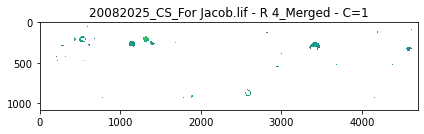

In [60]:
from vesicles import A10_muscope_crop

A10_muscope_crop.main(initval)

### I. Single-frame Data Processing

If the data is single-frame .tif files, we just collect all data points and save them in one file.

In [5]:
if initval.suffix == '.tif' and initval.sequence == 'single_frame':
    load_dirname = initval.mainpath_out + initval.subdir + "/A20b_processed/"
    csv_path_in = Path(load_dirname)
    
    # Collect data from all CSV files
    name, data = [], []
    for csv_source in csv_path_in.glob("**/*.csv"):
        print(csv_source.stem)
        with open(csv_source) as f:
            reader = csv.DictReader(f, delimiter=";")
            for row in reader:
                name.append(csv_source.stem)
                data.append(row)
    
    # Save collected data to a new CSV file
    csv_path_out = Path(initval.mainpath_out + initval.subdir + "/A30_processed/")
    csv_path_out.mkdir(exist_ok=True)
    
    csv_target = load_dirname + "collected_data.csv"
    with open(csv_target, "w", newline='') as csv_f:
        writer = csv.writer(csv_f, delimiter=";")
        writer.writerow(data[0].keys())
        for data_row in data:
            writer.writerow(data_row.values())

### II. Multi-frame Data Processing and Visualization

For time-trace or z-plane .tif files, we process the data and create visualizations. Since these movies can have some time slots-of-interest, we load an extra excel table that allows a user to crop dat a of processed movies (or discard them at all). Note that the 'movie-I' field should match the above movie-IDs.

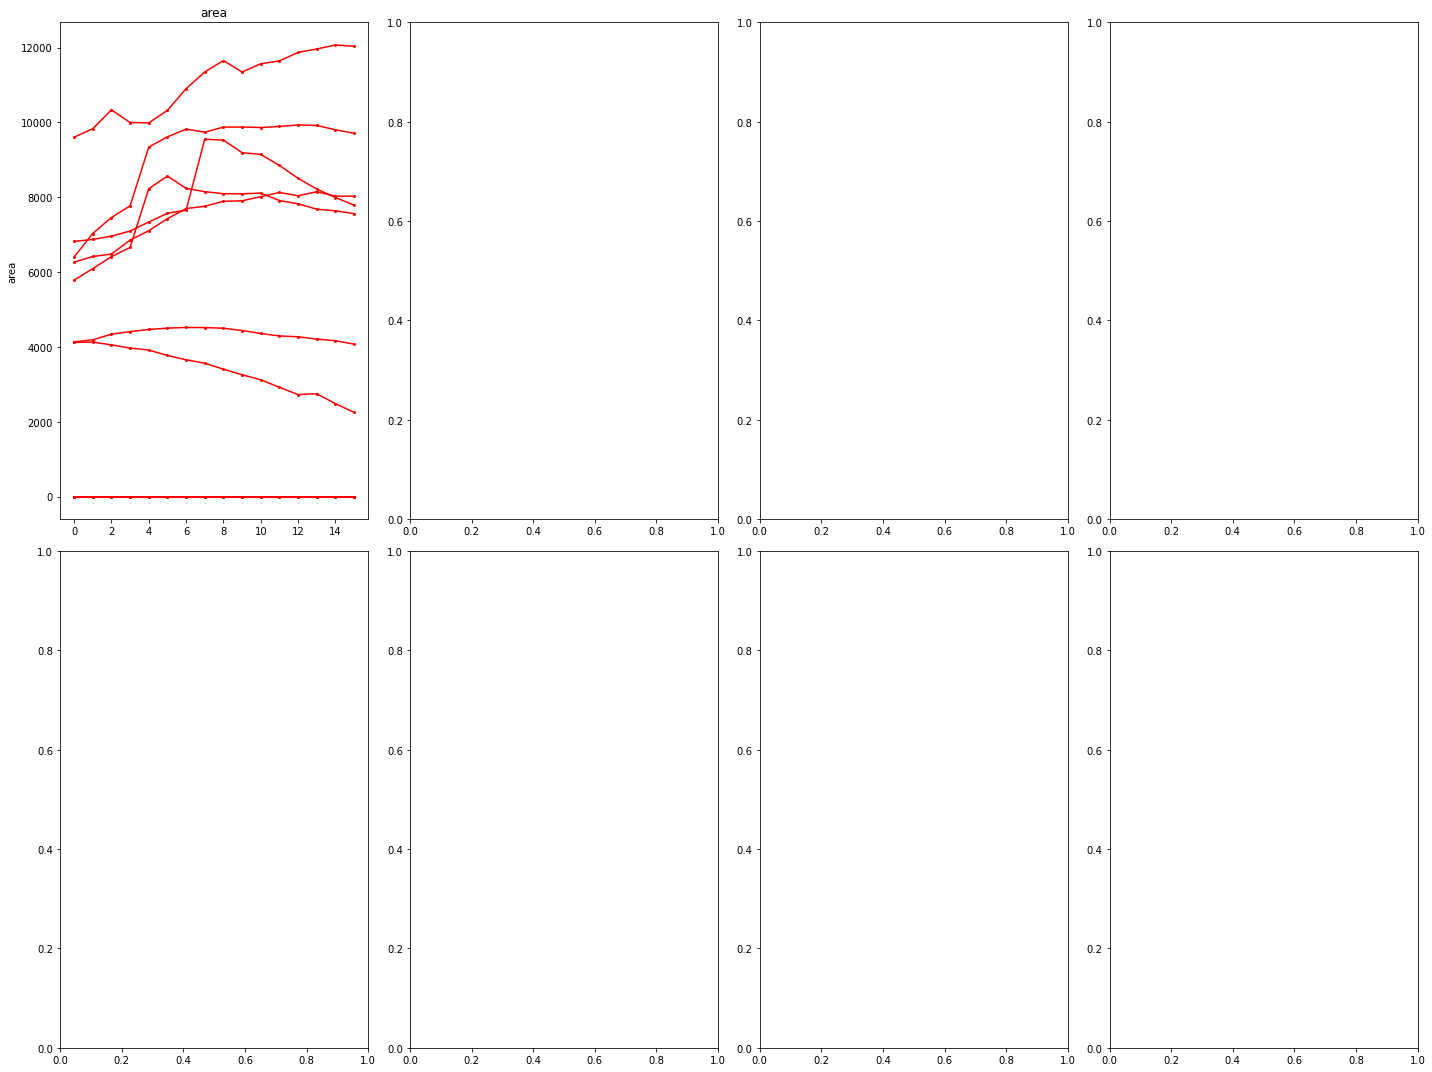

In [27]:
selections_filename="data_overview_Charu.xlsx"
Guv_list = get_data_selections(round(expi), selections_filename)

if initval.suffix == '.tif' and initval.sequence == 'time_trace':
    fig, axs = plt.subplots(2, 4, figsize=(20, 15))
    load_dirname_A20a = initval.mainpath_out + initval.subdir + "/A20a_tracked/"
    load_dirname_A20b = initval.mainpath_out + initval.subdir + "/A20b_processed/"    
    guv_labels = []    
    for this_guv in Guv_list:
        if this_guv.use_it == 1 and this_guv.movie_id in movie_to_use_list:
            movie_use_index = movie_to_use_list.index(this_guv.movie_id)
            guv_labels.append(this_guv.label)
            
            # Read data from CSV
            csv_source = Path(load_dirname_A20b + this_guv.label + "_all_data.csv")
            with open(csv_source) as g:
                reader = csv.DictReader(g, delimiter=";")
                data = list(reader)            
            # Process and plot data
            plot_ax, area, roundness, major_minor = [], [], [], []
            c0_edge_mx, c0_edge_sm = [], []
            
            for fri, row in enumerate(data):
                # ... (data processing code)
                c0_mean_peaks=(float(row['c0_edge_mx']))
                c0_sum=float(row['c0_edge_sum'])
                okay_point=1
                if okay_point:
                    #fetch work parameters:
                    axis_major=float(row['R_major'])
                    axis_minor=float(row['R_minor'])
                    c0_mean_peaks=(float(row['c0_edge_mx']))
                    #build plots:
                    if 1:
                        plot_ax.append(this_guv.dt*fri)
                        axlabel="time (s)"
                    area.append(float(row['area']))
                    roundness.append(float(row['roundness']))
                    c0_edge_mx.append(c0_mean_peaks)
                    c0_edge_sm.append(float(row['c0_edge_sum']))
            
            simbol_color = movie_simbol_list[movie_use_index]
            sz = 2            
            # Plot various metrics
            axs[0, 0].plot(plot_ax, area, 'o-', markersize=sz, color=simbol_color)
            axs[0, 0].set_ylabel("area")
            axs[0, 0].set_title("area")
            
            # ... (more plotting code for other metrics)    
    plt.tight_layout()
    plt.show()

This completes the GUV image analysis pipeline. The notebook processes both single-frame and time-trace .tif files, collecting data and creating visualizations for various GUV metrics.